# Data quality in AMP MIC prediction

This notebook is the data-side companion to the [peptideTransformer](https://github.com/dtischler95/peptideTransformer) Master's thesis. The thesis asks a simple question: **is the accuracy of MIC prediction limited by the model or by the data?**

The short answer from the thesis is *the data*. Antimicrobial peptide (AMP) activity is measured in the lab, and the same peptide measured twice rarely gives the exact same MIC. That experimental scatter puts a hard floor on how low any model's test error can go, no matter how big or clever the model is.

This notebook makes that argument concrete and reproducible, using only data shipped in this repository:

1. What the dataset looks like (sizes, peptide lengths, MIC distribution).
2. How often the same sequence was measured more than once (replicates).
3. How much those repeated measurements disagree (the per-sequence spread).
4. Turning that spread into a single number, the **measurement-noise floor**, and comparing it to the deployed model's test error.

The worked example is *Acinetobacter baumannii*, the organism behind the [deployed MIC prediction model](https://huggingface.co/danielt95/acinetobacter-baumannii-mic-bert). The model metrics themselves live in [RESULTS.md](../RESULTS.md), this notebook is about the data they were trained on.

The plotting and number-crunching live in `nb_utils.py`, so the cells below stay at the level of variables and named calls.

> Note on sources. The per-organism files in `data/regression_data/` are already de-duplicated (one row per sequence), so the replicate analysis below reads the raw measurements from `data/data_from_database/DBAASP_from_CalcAMP.csv` instead. The full thesis additionally merges `dbaasp_scraped.csv`, here we keep to the single DBAASP source for a clean, self-contained walk-through.

In [1]:
import sys
from pathlib import Path

# Make nb_utils importable whether this runs from the repo root or from notebooks/.
for _cand in (Path.cwd(), Path.cwd() / "notebooks"):
    if (_cand / "nb_utils.py").exists() and str(_cand) not in sys.path:
        sys.path.insert(0, str(_cand))
from nb_utils import *

REPO = find_repo_root()
ORGANISM = "Acinetobacter baumannii"
ORG_FILE = REPO / "data" / "regression_data" / "acinetobacter_baumannii_for_regression.csv"
ALL_FILES = all_organism_files(REPO)

print(f"repo: {REPO}")
print(f"organism files: {len(ALL_FILES)}")

repo: E:\Test\peptideTransformer
organism files: 12


## 1. The dataset at a glance

We start from the de-duplicated regression file: one row per unique peptide, with its MIC already log10-transformed (`mic_log10`, in log10 of µM). This is exactly the data the model is trained on.

In [2]:
df = load_organism(ORG_FILE)
summarize_dataset(df, ORGANISM)
df.head()

Organism:            Acinetobacter baumannii
Unique sequences:    1710
Sequence length:     3 - 36 residues
log10(MIC) range:    -1.61 .. 2.88
log10(MIC) mean/std: 1.06 / 0.75


,sequence,mic_log10,length
0,AAGKVLKLLKKLL,1.759668,13
1,AAKKGCWTVSIPPKPCF,1.204120,17
2,AAKKVLKLLKKLL,1.735200,13
3,AAWKKAAKKAAKSAKKAG,1.176091,18
4,AAYLLAKINLKALAALAKKIL,0.734628,21


## 2. The landscape across organisms

Before zooming in on the deployed model's organism, here is the whole MIC dataset at a glance: for each of the 12 organisms, the peptide-length distribution and the log10(MIC) distribution.

Across organisms the peptides cluster around 15 residues and most MIC values sit near 1.5 log10(µM). The shapes are broadly similar, the main difference is how much data each organism has.

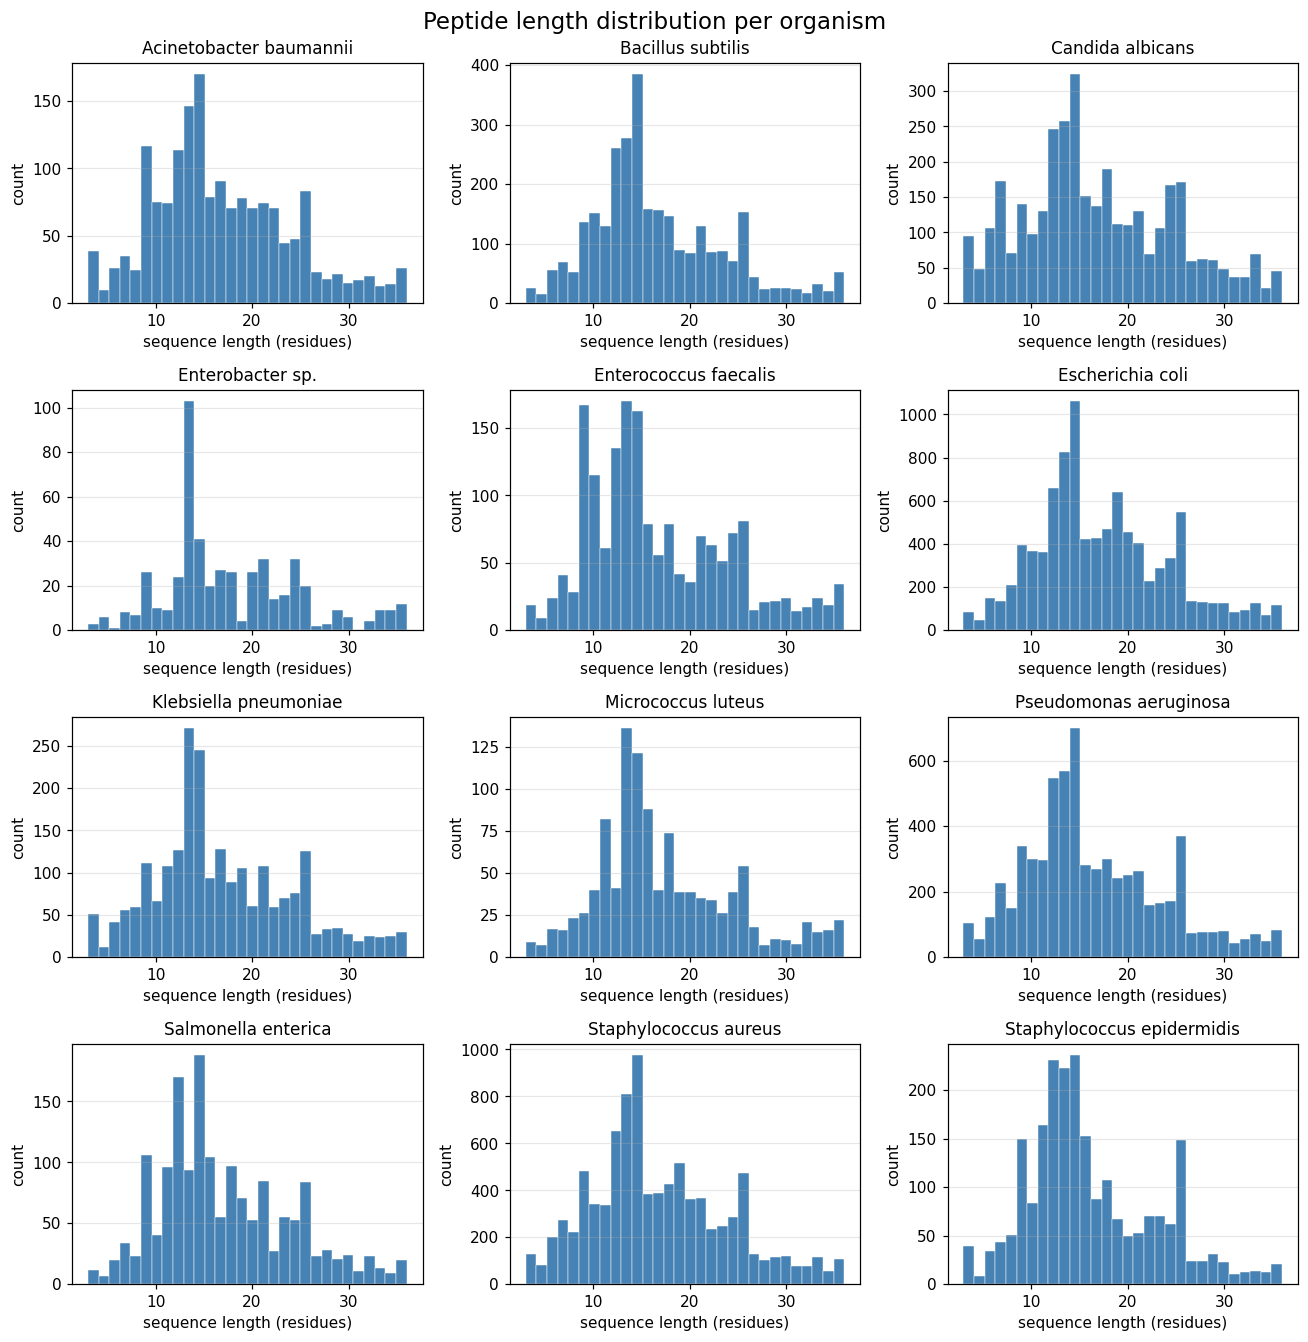

In [3]:
plot_length_grid(ALL_FILES)

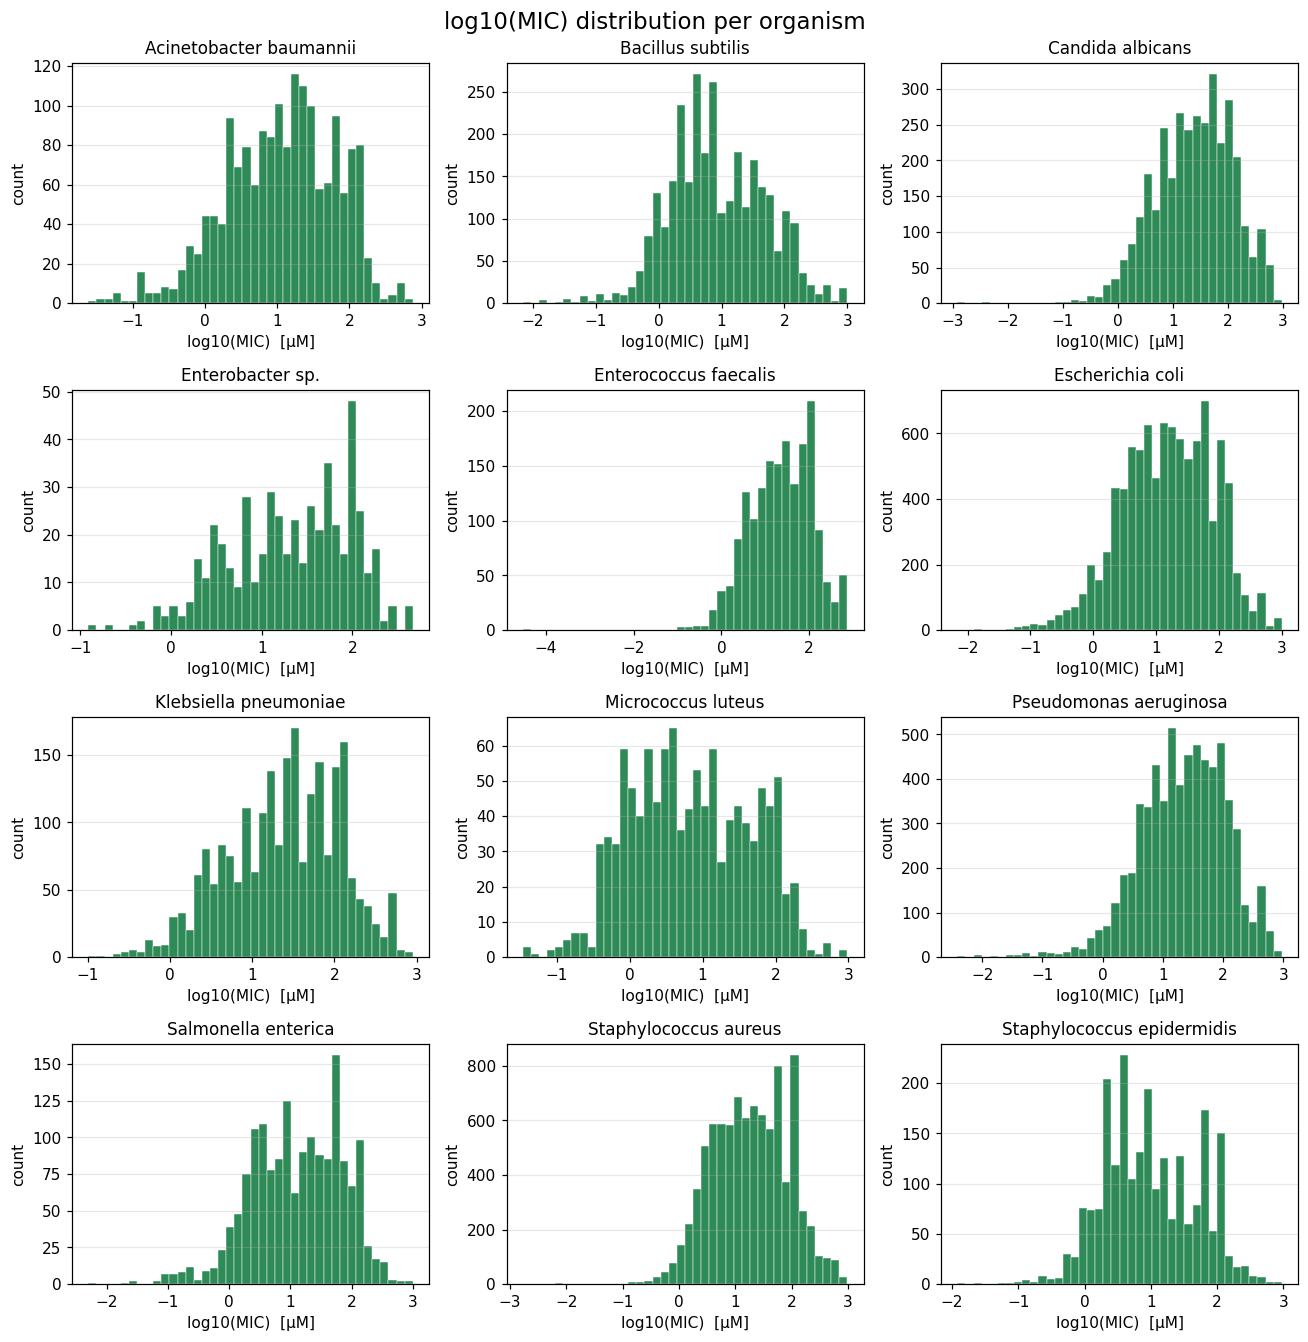

In [4]:
plot_mic_grid(ALL_FILES)

## 3. The same peptide, measured more than once

The de-duplicated files above keep one MIC per sequence, so the experimental scatter is already averaged away. To see that scatter we go back to the raw measurements in `DBAASP_from_CalcAMP.csv` and keep, for *Acinetobacter baumannii*:

- rows whose strain is an *Acinetobacter* and whose assay is `MIC`,
- sequences of 3 to 36 standard amino acids (the same sequence rule the training data uses),
- MIC values on the log10(µM) scale, the model's target.

Many sequences were measured several times. Those replicates are what let us quantify the noise.

raw MIC measurements (cleaned): 914
unique sequences:               595
measured >= 2 times:            191
max measurements on one seq:    14


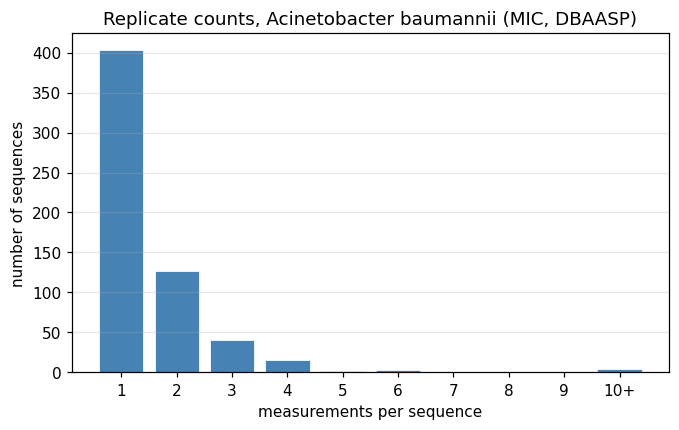

In [5]:
replicates = load_mic_replicates(REPO, strain="Acinetobacter")
replicate_summary(replicates)
plot_replicate_counts(replicates, ORGANISM)

## 4. How much do replicates disagree, and what it means for the model

For every sequence measured at least twice, take the standard deviation of its log10(MIC) measurements. That per-sequence spread is the experimental noise, the part of the target no model can recover from sequence alone. Averaging the within-sequence variance gives a single **measurement-noise floor**: the test error a perfect model would still pay.

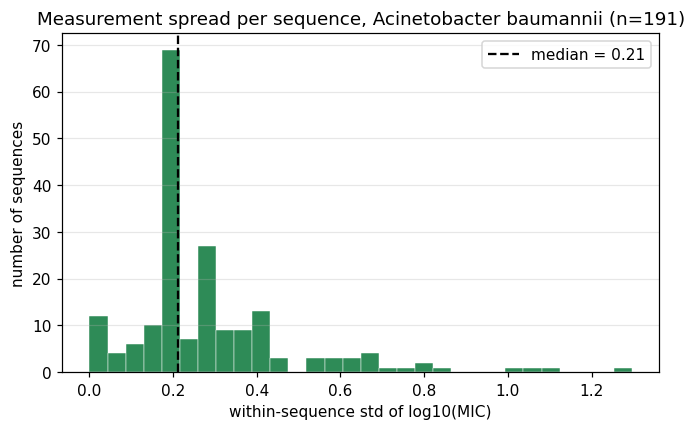

measurement-noise floor (from 191 replicated sequences)
  sigma_floor             : 0.356 log10(MIC)  (about 2.3-fold)
deployed model test RMSE  : 0.552 log10(MIC)
  noise share of test MSE : 42%


In [6]:
plot_sigma_per_sequence(replicates, ORGANISM)

MODEL_TEST_MSE = 0.305   # sequence-only BERT on A. baumannii, test MSE from RESULTS.md
floor = measurement_noise_floor(replicates, MODEL_TEST_MSE)

print(f"measurement-noise floor (from {floor['n_replicated']} replicated sequences)")
print(f"  sigma_floor             : {floor['sigma_floor']:.3f} log10(MIC)  (about {floor['fold']:.1f}-fold)")
print(f"deployed model test RMSE  : {floor['model_rmse']:.3f} log10(MIC)")
print(f"  noise share of test MSE : {floor['noise_share']:.0%}")

## Takeaways

- The same peptide measured twice routinely lands 2 to 3 fold apart in concentration. For *Acinetobacter baumannii* the measurement-noise floor here is about **0.36 log10(MIC)**, in line with the thesis estimate of about 0.4.
- Roughly **40% of the model's test-error variance is that irreducible measurement noise**, not something a bigger or smarter model could remove. The target itself is that noisy.
- That is the thesis' point in one number: a moderate R2 (about 0.45) here is largely a **data-quality ceiling**, not a modelling failure. Clean, de-duplicated, sequence-level splits report that ceiling honestly instead of hiding it. The point is not a high R2, it is an R2 you can trust.
- Scope note: this walk-through uses the single DBAASP source. The thesis combines more sources, so exact numbers shift a little, the conclusion does not.